# MLflow Review + Streamlit Introduction
### Review best model → Learn Streamlit → Build a working prototype

---

| Part | What we do |
|---|---|
| **Part A** | Review MLflow results and confirm the best model |
| **Part B** | Learn Streamlit from scratch |
| **Part C** | Prototype the forecast logic in the notebook |
| **Part D** | Write the working Streamlit app |

> **Before starting:** `W3-mlflow.ipynb` must have been run fully.
> The `models/` folder must exist in your project directory.

---
# Part A — Review MLflow results

We query MLflow directly from the notebook.
No browser UI needed.

## Step 1 — Set paths and connect to MLflow

In [1]:
import os
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── CHANGE THIS to your own project folder ───────────────────
PROJECT_DIR = r'C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series'                              

# ── These are set automatically — do not change ───────────────
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')                                 # this is where the data is stored, notebook will download the data automatically if it's not there
MLFLOW_PATH = os.path.join(PROJECT_DIR, 'mlruns')                               # this is where MLflow will store the runs, you can open this folder with the MLflow UI to see the results
MODELS_DIR  = os.path.join(PROJECT_DIR, 'models')                               # this is where the best model will be saved, W3-streamlit.ipynb will load the model from here

# ── Connect to MLflow ─────────────────────────────────────────
mlflow.set_tracking_uri("file:///" + MLFLOW_PATH.replace("\\", "/"))            # set MLflow tracking URI to the mlruns folder in the project directory

# ── Verify all folders exist ──────────────────────────────────
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:   ", DATA_DIR)
print("MODELS_DIR: ", MODELS_DIR)
print()
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("DATA_DIR exists:   ", os.path.exists(DATA_DIR))
print("MODELS_DIR exists: ", os.path.exists(MODELS_DIR))

if not os.path.exists(MODELS_DIR):
    print()
    print("WARNING: models/ folder not found.")
    print("Make sure W3-mlflow.ipynb was run fully before this notebook.")

c:\Users\alipa\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_DIR: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series
DATA_DIR:    C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\data
MODELS_DIR:  C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\models

PROJECT_DIR exists: True
DATA_DIR exists:    True
MODELS_DIR exists:  True


## Step 2 — Load the best model name and confirm it

In [2]:
# ── Read the best model name saved by W3-mlflow.ipynb ─────────
name_path  = os.path.join(MODELS_DIR, 'best_model_name.txt')

if os.path.exists(name_path):
    with open(name_path) as f:
        best_model_name = f.read().strip()
    print(f"Best model: {best_model_name}")
else:
    print("best_model_name.txt not found.")
    print(f"Expected at: {name_path}")
    print("Run W3-mlflow.ipynb fully before continuing.")
    best_model_name = None

Best model: Holt-Winters


## Step 3 — Review all MLflow runs

In [3]:
# ── Pull all logged runs into a DataFrame ─────────────────────
client     = mlflow.tracking.MlflowClient()                                     # Create an MLflow client to interact with the tracking server
experiment = client.get_experiment_by_name("retail_sales_forecasting")          # Get the experiment by name, this should match the name used in W3-mlflow.ipynb when logging the runs

if experiment is None:
    print("Experiment not found. Run W3-mlflow.ipynb first.")
else:
    print(f"Experiment found: {experiment.name}")
    print()

    runs = client.search_runs(                                                  # Search for runs in the experiment, this will return a list of Run objects
        experiment_ids=[experiment.experiment_id],                              
        order_by=["start_time DESC"]
    )

    rows = []
    for run in runs:
        rows.append({
            'run_name':  run.info.run_name,
            'MAE':       run.data.metrics.get('MAE'),
            'RMSE':      run.data.metrics.get('RMSE'),
            'MAPE':      run.data.metrics.get('MAPE'),
            'Bias':      run.data.metrics.get('Bias'),
            'R2':        run.data.metrics.get('R2'),
        })

    df_runs = pd.DataFrame(rows).dropna(subset=['MAE'])

    # Keep only the most recent run per model name
    df_runs = df_runs.drop_duplicates(subset='run_name', keep='first')          # This keeps only the most recent one for each model
    df_runs = df_runs.sort_values('MAE').reset_index(drop=True)

    print("All logged runs — sorted by MAE (best first):")
    print()
    print(df_runs[['run_name','MAE','RMSE','MAPE','Bias','R2']].to_string(index=False))

Experiment found: retail_sales_forecasting

All logged runs — sorted by MAE (best first):

          run_name    MAE   RMSE  MAPE    Bias     R2
BEST__Holt-Winters  94.83 143.07  21.0   -9.12  0.392
      Holt-Winters  94.83 143.07  21.0   -9.12  0.392
             ARIMA  95.65 143.68  21.2   -9.29  0.386
   XGBoost (tuned)  96.30 141.45  22.0   -2.19  0.405
XGBoost (baseline) 108.60 155.72  24.8    5.53  0.279
           Prophet 156.53 201.94  30.9 -144.59 -0.212
              LSTM 174.05 207.29  46.1   94.79 -0.277


---
# Part B — Introduction to Streamlit

## What is Streamlit?

Streamlit turns a plain `.py` script into an interactive web app — no HTML or JavaScript needed.

| | What it is | How you use it |
|---|---|---|
| `streamlit` (the package) | A Python library | `import streamlit as st` in a `.py` file |
| `streamlit run` (the command) | A terminal command | `python -m streamlit run app.py` in Command Prompt |

> You never run Streamlit inside a notebook cell.
> Write your app in a `.py` file, then launch it from Command Prompt.

### Key commands

| Command | What it does |
|---|---|
| `st.title()` | Large heading at the top |
| `st.write()` | Display text, tables, or numbers |
| `st.date_input()` | Date picker widget |
| `st.slider()` | Numeric slider |
| `st.selectbox()` | Dropdown menu |
| `st.button()` | Clickable button |
| `st.pyplot()` | Display a matplotlib chart |
| `st.dataframe()` | Display a table |
| `st.sidebar` | Move widgets to the left sidebar |
| `st.download_button()` | Let users download a file |
| `st.spinner()` | Show a loading message |
| `st.success()` | Green success message |
| `st.error()` | Red error message |
| `st.cache_data` | Cache data so it loads only once |
| `st.cache_resource` | Cache a model so it loads only once |

Official docs: https://docs.streamlit.io/develop/api-reference  
Date input: https://docs.streamlit.io/develop/api-reference/widgets/st.date_input

## Step 4 — Install Streamlit

In [4]:
# Run this cell once
! pip install streamlit -q

import streamlit
print("Streamlit version:", streamlit.__version__)

# Follow these instructions to set up the Streamlit in your command prompt:
# 1. Open Command Prompt (Windows) or Terminal (Mac/Linux)
# 2. Navigate to your project directory:
#    cd C:\PATH\TO\YOUR\PROJECT]
# 3. Install Streamlit in your command prompt:
#    pip install streamlit
# 3. Run the Streamlit app:
#    streamlit run xxx.py
# 4. A web browser window will open with the Streamlit app


Streamlit version: 1.57.0


## Step 5 — Hello World example

In [5]:
# ── Write hello_world.py to the project folder ───────────────
hello_path = os.path.join(PROJECT_DIR, 'hello_world.py')            # this is a simple Streamlit app to test that everything is working

hello_code = '''import streamlit as st
import pandas as pd
import numpy as np

st.title("Hello, Streamlit!")
st.write("This is your first Streamlit app.")

st.header("1. Text")
st.write("Use st.write() to display anything.")

st.header("2. User input")
selected_date = st.date_input("Pick a date")
st.write(f"You selected: {selected_date}")

model_choice = st.selectbox("Choose a model", ["XGBoost", "ARIMA", "Prophet", "Holt-Winters"])
st.write(f"You chose: {model_choice}")

days_ahead = st.slider("Days to forecast", min_value=1, max_value=30, value=7)
st.write(f"Forecasting {days_ahead} days ahead.")

st.header("3. Button")
if st.button("Click me"):
    st.success("Button clicked!")

st.header("4. Chart")
sample = pd.DataFrame({
    "Day": range(1, 31),
    "Sales": np.random.randint(300, 700, 30)
}).set_index("Day")
st.line_chart(sample)
'''

with open(hello_path, 'w') as f:                                # write the hello_code string to the hello_world.py file in the project directory
    f.write(hello_code)

print(f"File written to: {hello_path}")
print()
print("To launch, open Command Prompt and run:")
print(f"  cd {PROJECT_DIR}")                                    # change directory to the project folder
print("  python -m streamlit run app_prototype.py")             # run the Streamlit app, replace app_prototype.py with the name of your Streamlit app file
print()
print("Then open http://localhost:8501 in your browser.")

File written to: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\hello_world.py

To launch, open Command Prompt and run:
  cd C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series
  python -m streamlit run app_prototype.py

Then open http://localhost:8501 in your browser.


---
# Part C — Prototype the forecast logic in the notebook

> **Key principle:** Always build and test your Python logic here first.
> Debugging in a notebook is much easier than debugging inside a Streamlit app.
> Once everything works here, moving it to `app.py` is straightforward.

## Step 6 — Load data and best model

In [6]:
# ── Load the feature-engineered dataset ──────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'timeseries_with_features.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date').dropna()

print("Data loaded!")
print("Shape:     ", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())

Data loaded!
Shape:      (422, 24)
Date range: 2013-02-01 to 2014-03-31


In [7]:
# ── Feature columns — same as W3-mlflow.ipynb ────────────────
FEATURES = [
    'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year',
    'is_weekend', 'is_month_start', 'is_month_end',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std',
    'dcoilwtico', 'oil_lag_1', 'oil_rolling_7d_mean',
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
]
TARGET = 'unit_sales'
print("Features defined:", len(FEATURES))

Features defined: 23


In [8]:
# ── Load the best model saved by W3-mlflow.ipynb ─────────────

def load_best_model(models_dir):                                            # define a function to load the best model from disk
    """
    Loads the best model from disk.
    Works for XGBoost, ARIMA, Holt-Winters, Prophet, and LSTM.
    """
    pkl_path = os.path.join(models_dir, 'best_model.pkl')                   # This is the file where W3-mlflow.ipynb saves the best model (.pkl file for most models) and .pt file for LSTM
    pt_path  = os.path.join(models_dir, 'best_model.pt')

    if os.path.exists(pkl_path):
        model = joblib.load(pkl_path)                                       # Load the model using joblib, this works for XGBoost, ARIMA, Holt-Winters, and Prophet
        print(f"Model loaded from: {pkl_path}")
        print(f"Model type: {type(model).__name__}")
        return model

    elif os.path.exists(pt_path):
        import torch
        import torch.nn as nn

        class SimpleLSTM(nn.Module):
            def __init__(self, hidden=64):
                super().__init__()
                self.lstm   = nn.LSTM(1, hidden, batch_first=True)
                self.linear = nn.Linear(hidden, 1)
            def forward(self, x):
                out, _ = self.lstm(x)
                return self.linear(out[:, -1, :])

        model = SimpleLSTM(hidden=64)
        model.load_state_dict(torch.load(pt_path))
        model.eval()
        print(f"LSTM model loaded from: {pt_path}")
        return model

    else:
        print("No model file found.")
        print(f"Expected location: {models_dir}")
        print("Run W3-mlflow.ipynb fully before continuing.")
        return None

model = load_best_model(MODELS_DIR)                                         # Load the best model from disk, this will be used in the Streamlit app to make predictions

Model loaded from: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\models\best_model.pkl
Model type: HoltWintersResultsWrapper


## Step 7 — Define and test the forecast function

In [9]:
def make_forecast(df, model, features, cutoff_date, n_days=1):          # define a function to make a forecast using the loaded model then used in the Streamlit app
    """
    Generates a forecast for n_days starting after cutoff_date.
    Automatically handles XGBoost, ARIMA, Holt-Winters, and Prophet.

    Parameters:
        df          : full feature-engineered DataFrame
        model       : trained model object
        features    : list of feature column names (used by XGBoost only)
        cutoff_date : forecast starts the day after this date
        n_days      : number of days to forecast

    Returns:
        DataFrame with columns ['date', 'forecast']
    """
    cutoff     = pd.to_datetime(cutoff_date)                            # ensure cutoff_date is a Timestamp
    model_type = type(model).__name__

    # ── ARIMA / SARIMAX ──────────────────────────────────────
    # Uses forecast() from the last training date — no feature row needed
    if 'SARIMAXResults' in model_type or 'ARIMAResults' in model_type:  # check if the model is an ARIMA or SARIMAX model by looking for these substrings in the class name
        preds = model.forecast(steps=n_days)
        forecasts = [
            {'date': cutoff + pd.Timedelta(days=i+1),
             'forecast': round(float(max(0, p)), 2)}
            for i, p in enumerate(preds)
        ]
        return pd.DataFrame(forecasts).set_index('date')

    # ── Holt-Winters ─────────────────────────────────────────
    # Uses forecast() exactly like ARIMA
    elif 'HoltWintersResults' in model_type or 'ExponentialSmoothing' in model_type:    # check if the model is a Holt-Winters model by looking for these substrings in the class name
        preds = model.forecast(n_days)
        forecasts = [
            {'date': cutoff + pd.Timedelta(days=i+1),
             'forecast': round(float(max(0, p)), 2)}
            for i, p in enumerate(preds)
        ]
        return pd.DataFrame(forecasts).set_index('date')

    # ── Prophet ──────────────────────────────────────────────
    # Requires a future DataFrame with a 'ds' column
    elif 'Prophet' in model_type:                       # check if the model is a Prophet model by looking for this substring in the class name 
        future_dates = pd.date_range(
            start=cutoff + pd.Timedelta(days=1),
            periods=n_days,
            freq='D'
        )
        future_df    = pd.DataFrame({'ds': future_dates})       # Prophet requires a DataFrame with a 'ds' column for the future dates
        forecast_out = model.predict(future_df)
        forecasts = [
            {'date': row['ds'],
             'forecast': round(float(max(0, row['yhat'])), 2)}
            for _, row in forecast_out.iterrows()
        ]
        return pd.DataFrame(forecasts).set_index('date')

    # ── XGBoost / sklearn-compatible models ──────────────────
    # Uses feature rows — one prediction per day
    else:
        history   = df.loc[df.index <= cutoff].copy()                  
        forecasts = []

        if len(history) == 0:
            raise ValueError(f"No data found on or before {cutoff_date}.")

        for i in range(n_days):
            next_date = cutoff + pd.Timedelta(days=i+1)

            if next_date in df.index:
                row = df.loc[[next_date], features]
            else:
                row = history.iloc[[-1]][features].copy()
                row.index = [next_date]

            pred = model.predict(row)[0]
            pred = max(0, pred)
            forecasts.append({
                'date':     next_date,
                'forecast': round(float(pred), 2)
            })

        return pd.DataFrame(forecasts).set_index('date')                        # Return a DataFrame with the forecasts, indexed by date

In [10]:
# ── Test: single day forecast ─────────────────────────────────
cutoff        = '2014-01-01'
forecast_1day = make_forecast(df, model, FEATURES, cutoff, n_days=1)            # make a 1-day forecast starting after the cutoff date, this will be used in the Streamlit app
print("Single day forecast:")
print(forecast_1day)
print()

# ── Test: 7-day forecast ──────────────────────────────────────
forecast_7day = make_forecast(df, model, FEATURES, cutoff, n_days=7)            # make a 7-day forecast starting after the cutoff date, this will be used in the Streamlit app
print("7-day forecast:")
print(forecast_7day)

Single day forecast:
            forecast
date                
2014-01-02    456.53

7-day forecast:
            forecast
date                
2014-01-02    456.53
2014-01-03    346.46
2014-01-04    387.33
2014-01-05    624.91
2014-01-06    696.44
2014-01-07    438.00
2014-01-08    385.47


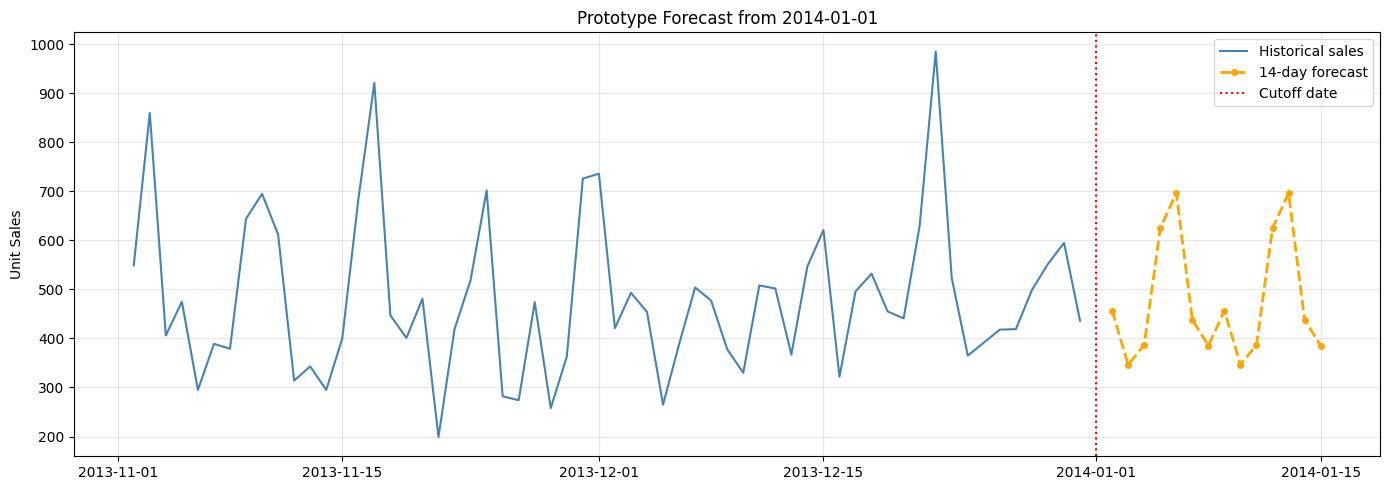

Prototype chart working. Ready to move to app_prototype.py.


In [11]:
# ── Prototype chart ───────────────────────────────────────────
cutoff       = pd.to_datetime('2014-01-01')                                     # This is the cutoff date for the forecast
n_days       = 14
history_days = 60

history_plot  = df.loc[
    (df.index >= cutoff - pd.Timedelta(days=history_days)) &
    (df.index <= cutoff)
][TARGET]

forecast_plot = make_forecast(df, model, FEATURES, cutoff, n_days=n_days)       # Generate a forecast for n_days starting after the cutoff date, this will be plotted on the chart

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history_plot.index, history_plot.values,
        label='Historical sales', color='steelblue', linewidth=1.5)
ax.plot(forecast_plot.index, forecast_plot['forecast'].values,
        label=f'{n_days}-day forecast', color='orange',
        linestyle='--', linewidth=2, marker='o', markersize=4)
ax.axvline(cutoff, color='red', linestyle=':', linewidth=1.5, label='Cutoff date')
ax.set_title(f'Prototype Forecast from {cutoff.date()}')
ax.set_ylabel('Unit Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Prototype chart working. Ready to move to app_prototype.py.")

---
# Part D — Write the Streamlit prototype app

Now that the logic works in the notebook, we write it into `app_prototype.py`.
Day 3 will polish this further and deploy it to Streamlit Cloud.

## Step 8 — Write app_prototype.py

In [12]:
app_path = os.path.join(PROJECT_DIR, 'app_prototype.py')    # this is the main Streamlit app file that will be launched to interact with the model and make forecasts

app_code = '''# Retail Sales Forecasting App — Prototype
# Built in Day 2. Polished and deployed in Day 3.
#
# To launch:
#   Open Command Prompt
#   cd ''' + PROJECT_DIR + '''
#   python -m streamlit run app_prototype.py

import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
from datetime import date

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────
PROJECT_DIR = r"''' + PROJECT_DIR + '''"
DATA_DIR    = os.path.join(PROJECT_DIR, "data")
MODELS_DIR  = os.path.join(PROJECT_DIR, "models")

FEATURES = [
    "year", "month", "day", "dayofweek", "quarter", "week_of_year",
    "is_weekend", "is_month_start", "is_month_end",
    "lag_1", "lag_7", "lag_14", "lag_30",
    "rolling_7d_mean", "rolling_14d_mean", "rolling_30d_mean", "rolling_7d_std",
    "dcoilwtico", "oil_lag_1", "oil_rolling_7d_mean",
    "is_national_holiday", "is_regional_holiday", "is_local_holiday",
]
TARGET = "unit_sales"

# ── Load data (cached — runs once) ───────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv(os.path.join(DATA_DIR, "timeseries_with_features.csv"))
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").set_index("date").dropna()

# ── Load model (cached — runs once) ──────────────────────────
@st.cache_resource
def load_model():
    pkl_path = os.path.join(MODELS_DIR, "best_model.pkl")
    pt_path  = os.path.join(MODELS_DIR, "best_model.pt")

    if os.path.exists(pkl_path):
        return joblib.load(pkl_path)

    elif os.path.exists(pt_path):
        import torch
        import torch.nn as nn
        class SimpleLSTM(nn.Module):
            def __init__(self, hidden=64):
                super().__init__()
                self.lstm   = nn.LSTM(1, hidden, batch_first=True)
                self.linear = nn.Linear(hidden, 1)
            def forward(self, x):
                out, _ = self.lstm(x)
                return self.linear(out[:, -1, :])
        model = SimpleLSTM(hidden=64)
        model.load_state_dict(torch.load(pt_path))
        model.eval()
        return model

    else:
        return None

# ── Load best model name ──────────────────────────────────────
def load_model_name():
    name_path = os.path.join(MODELS_DIR, "best_model_name.txt")
    if os.path.exists(name_path):
        with open(name_path) as f:
            return f.read().strip()
    return "Unknown"

# ── Forecast function ─────────────────────────────────────────
def make_forecast(df, model, features, cutoff_date, n_days=1):
    """
    Generates a forecast for n_days starting after cutoff_date.
    Automatically handles XGBoost, ARIMA, Holt-Winters, and Prophet.

    Parameters:
        df          : full feature-engineered DataFrame
        model       : trained model object
        features    : list of feature column names (used by XGBoost only)
        cutoff_date : forecast starts the day after this date
        n_days      : number of days to forecast

    Returns:
        DataFrame with columns ['date', 'forecast']
    """
    cutoff     = pd.to_datetime(cutoff_date)
    model_type = type(model).__name__

    # ── ARIMA / SARIMAX ──────────────────────────────────────
    # Uses forecast() from the last training date — no feature row needed
    if 'SARIMAXResults' in model_type or 'ARIMAResults' in model_type:
        preds = model.forecast(steps=n_days)
        forecasts = [
            {'date': cutoff + pd.Timedelta(days=i+1),
             'forecast': round(float(max(0, p)), 2)}
            for i, p in enumerate(preds)
        ]
        return pd.DataFrame(forecasts).set_index('date')

    # ── Holt-Winters ─────────────────────────────────────────
    # Uses forecast() exactly like ARIMA
    elif 'HoltWintersResults' in model_type or 'ExponentialSmoothing' in model_type:
        preds = model.forecast(n_days)
        forecasts = [
            {'date': cutoff + pd.Timedelta(days=i+1),
             'forecast': round(float(max(0, p)), 2)}
            for i, p in enumerate(preds)
        ]
        return pd.DataFrame(forecasts).set_index('date')

    # ── Prophet ──────────────────────────────────────────────
    # Requires a future DataFrame with a 'ds' column
    elif 'Prophet' in model_type:
        future_dates = pd.date_range(
            start=cutoff + pd.Timedelta(days=1),
            periods=n_days,
            freq='D'
        )
        future_df    = pd.DataFrame({'ds': future_dates})
        forecast_out = model.predict(future_df)
        forecasts = [
            {'date': row['ds'],
             'forecast': round(float(max(0, row['yhat'])), 2)}
            for _, row in forecast_out.iterrows()
        ]
        return pd.DataFrame(forecasts).set_index('date')

    # ── XGBoost / sklearn-compatible models ──────────────────
    # Uses feature rows — one prediction per day
    else:
        history   = df.loc[df.index <= cutoff].copy()
        forecasts = []

        if len(history) == 0:
            raise ValueError(f"No data found on or before {cutoff_date}.")

        for i in range(n_days):
            next_date = cutoff + pd.Timedelta(days=i+1)

            if next_date in df.index:
                row = df.loc[[next_date], features]
            else:
                row = history.iloc[[-1]][features].copy()
                row.index = [next_date]

            pred = model.predict(row)[0]
            pred = max(0, pred)
            forecasts.append({
                'date':     next_date,
                'forecast': round(float(pred), 2)
            })

        return pd.DataFrame(forecasts).set_index('date')

# ── App layout ────────────────────────────────────────────────
st.title("Retail Sales Forecasting")
st.write("Corporacion Favorita — Guayas region")

model_name = load_model_name()
st.info(f"Active model: {model_name}")

# Sidebar
st.sidebar.header("Forecast settings")

cutoff_date = st.sidebar.date_input(
    "Cutoff date",
    value=date(2014, 1, 15),
    min_value=date(2013, 6, 1),
    max_value=date(2014, 3, 30),
    help="Forecast starts the day after this date."
)

n_days = st.sidebar.slider("Days to forecast", 1, 30, 7)
history_days = st.sidebar.slider("History days to show", 14, 120, 60)
run_button = st.sidebar.button("Run Forecast")

# Main panel
if run_button:
    model = load_model()

    if model is None:
        st.error("Model not found. Run W3-mlflow.ipynb first.")
    else:
        with st.spinner("Loading data..."):
            df = load_data()

        with st.spinner("Generating forecast..."):
            cutoff       = pd.to_datetime(cutoff_date)
            history_plot = df.loc[
                (df.index >= cutoff - pd.Timedelta(days=history_days)) &
                (df.index <= cutoff)
            ][TARGET]
            forecast_df = make_forecast(df, model, FEATURES, cutoff, n_days)

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(history_plot.index, history_plot.values,
                label="Historical sales", color="steelblue", linewidth=1.5)
        ax.plot(forecast_df.index, forecast_df["forecast"].values,
                label=f"{n_days}-day forecast", color="orange",
                linestyle="--", linewidth=2, marker="o", markersize=4)
        ax.axvline(cutoff, color="red", linestyle=":", linewidth=1.5, label="Cutoff date")
        ax.set_title(f"Sales Forecast from {cutoff.date()}")
        ax.set_ylabel("Unit Sales")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig)

        st.subheader("Forecast values")
        st.dataframe(forecast_df.reset_index().rename(
            columns={"date": "Date", "forecast": "Predicted Sales"}
        ))

        csv = forecast_df.reset_index().to_csv(index=False)
        st.download_button(
            label="Download forecast as CSV",
            data=csv,
            file_name=f"forecast_{cutoff_date}.csv",
            mime="text/csv"
        )

        st.success("Forecast complete!")

else:
    st.info("Adjust the settings in the sidebar and click Run Forecast.")
    st.write("**Data range:** January 2013 – March 2014")
'''

with open(app_path, 'w', encoding='utf-8') as f:          # write the app_code string to the app_prototype.py file in the project directory, this is the main Streamlit app that will be launched
    f.write(app_code)

print(f"app_prototype.py written to: {app_path}")
print()
print("To launch, open Command Prompt and run:")
print(f"  cd {PROJECT_DIR}")
print(" python -m streamlit run app_prototype.py")
print()
print("Then open http://localhost:8501 in your browser.")


app_prototype.py written to: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\app_prototype.py

To launch, open Command Prompt and run:
  cd C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series
 python -m streamlit run app_prototype.py

Then open http://localhost:8501 in your browser.


---
## Summary

| Step | What we did |
|---|---|
| MLflow review | Queried all runs, confirmed best model |
| Streamlit concepts | Package vs command, key components |
| Hello World | Wrote and launched hello_world.py |
| Prototype logic | Tested make_forecast() in the notebook |
| Prototype app | Wrote app_prototype.py — launches locally |

---
### What comes next — Day 3

- Polish `app_prototype.py` into the final `app.py`
- Add error handling and store/item filters
- Create `requirements.txt` and `README.md`
- Push everything to GitHub
- Deploy to Streamlit Community Cloud

---
> **GitHub commit:**
> Add `W3-streamlit.ipynb`, `hello_world.py`, `app_prototype.py`
> Message: `"W3: Streamlit intro and prototype app"`